# Peak Detection with MI Signals - RR:

In [13]:
%load_ext autoreload
%autoreload 2
# %matplotlib qt
from ma.utils import load_all_signals, load_participant_data, put_metadata_to_segments
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from ma.utils import load_all_reference_signals
from scipy.signal import find_peaks
from ma.gp_utils import calculate_hr_or_rr
from scipy.ndimage import gaussian_filter1d

plt.rcParams['pgf.preamble'] = r'\usepackage{tikz}'

CLASS_NAME = "RR"
REF_SIGNAL = "resp_ref"
SIGNAL_TYPE = "MI"
SIGNAL = "mi1"

# Get the discriminated data:
all_data = load_all_signals(signal_type=SIGNAL_TYPE, bandpassed=True, normalized=False, class_name=CLASS_NAME)
ref_data = load_all_reference_signals(REF_SIGNAL, CLASS_NAME)

# Get the classes
good_no_ma = []
good_ma = []
bad_no_ma = []
bad_ma = []
noisy_no_ma = []
noisy_ma = []

for segment_no, segment in enumerate(all_data):
    if segment.attrs[f"{SIGNAL}_sq"] == 0 and segment.attrs[f"{SIGNAL}_ma"] == 0:
        good_no_ma.append(segment_no)
    if segment.attrs[f"{SIGNAL}_sq"] == 0 and segment.attrs[f"{SIGNAL}_ma"] == 1:
        good_ma.append(segment_no)
    if segment.attrs[f"{SIGNAL}_sq"] == 1 and segment.attrs[f"{SIGNAL}_ma"] == 0:
        bad_no_ma.append(segment_no)
    if segment.attrs[f"{SIGNAL}_sq"] == 1 and segment.attrs[f"{SIGNAL}_ma"] == 1:
        bad_ma.append(segment_no)
    if segment.attrs[f"{SIGNAL}_sq"] == 2 and segment.attrs[f"{SIGNAL}_ma"] == 0:
        noisy_no_ma.append(segment_no)
    if segment.attrs[f"{SIGNAL}_sq"] == 2 and segment.attrs[f"{SIGNAL}_ma"] == 1:
        noisy_ma.append(segment_no)

# For Reference Signal
def scg_peak_detection(
    df_segmented: list[pd.DataFrame],
    signal_name: str,
    distance=200,
    dynamic_height_multiplier=0.3,
    prominence=0.5,
    sigma = 50
) -> list[int]:
    all_peaks = []
    for segment in df_segmented:
        segment = segment[signal_name]
        # Apply a gaussian filter to smooth the segment
        smoothed_segment = gaussian_filter1d(segment, sigma=sigma)

        # Calculate a dynamic height based on the smoothed signal
        dynamic_height = np.mean(smoothed_segment) + dynamic_height_multiplier * np.std(
            smoothed_segment
        )

        # Detect peaks on the smoothed signal with the specified parameters
        peaks, _ = find_peaks(
            smoothed_segment,
            distance=distance,
            height=dynamic_height,
            prominence=prominence,
        )

        all_peaks.append(peaks)
    return all_peaks

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
def get_random_signals(
    signal1: tuple[str], signal2: tuple[str], signal3: tuple[str]
) -> list[pd.DataFrame]:
    conditions_map = {
        ("good", "no_ma"): good_no_ma,
        ("good", "ma"): good_ma,
        ("bad", "no_ma"): bad_no_ma,
        ("bad", "ma"): bad_ma,
        ("noisy", "no_ma"): noisy_no_ma,
        ("noisy", "ma"): noisy_ma,
    }

    def get_random_segment(condition):
        if condition in conditions_map and conditions_map[condition]:
            return random.choice(conditions_map[condition])
        return None

    random_segments = []
    for signal in [signal1, signal2, signal3]:
        segment_no = get_random_segment(signal)
        if segment_no is not None:
            random_segments.append(all_data[segment_no])

    return random_segments

def peak_detection(segment, distance=200, dynamic_height_multiplier=0.001, prominence=0.001):
    # Gaussian Smoothing:
    sigma = 10 # std for gaussian kernel
    smoothed_segment = gaussian_filter1d(segment, sigma=sigma)
    
    # Calculate a dynamic height based on the smoothed signal
    dynamic_height = np.mean(smoothed_segment) + dynamic_height_multiplier * np.std(smoothed_segment)
    
    # Detect peaks on the smoothed signal with the specified parameters
    peaks, _ = find_peaks(smoothed_segment, distance=distance, height=dynamic_height, prominence=prominence)
                
    return np.array(peaks)

In [15]:
def plot_rr_signal(df:pd.DataFrame, peaks:list, ax, label: str) -> None:
    df_copy = df.copy()
    # df_copy.index = (df_copy.index - df_copy.index[0]).total_seconds()
    df_hr = calculate_hr_or_rr(df_parti_segmented=[df_copy], peaks=[peaks], class_name="RR")
    plot_indexes = [df.index[0] + index for index in df_hr.index]
    ax.plot(plot_indexes, df_hr["rr"], marker="o", label= label)
    ax.grid()

def plot_reference_signal(df:pd.DataFrame, ax, legend:bool = False) -> None:
    parti_no = int(df.attrs["signal"].split("parti: ")[-1].split(" ")[0])
    filtered_ref_data = ref_data[ref_data["parti"] == parti_no]
    ref_start = np.argmin(abs(filtered_ref_data.index - df.index[0]))
    ref_stop = np.argmin(abs(filtered_ref_data.index - df.index[-1]))
    df_ref = filtered_ref_data.iloc[ref_start:ref_stop]

    ax2 = ax.twinx()    
    ax2.plot(            
        df_ref.index,
        df_ref[REF_SIGNAL],
        color="orange",
        alpha=0.3,
        label="Reference Respiratory Signal",
    )

    # Reference Signal Peaks:
    peaks_ref = scg_peak_detection(df_segmented = [df_ref], signal_name="resp_ref", distance=20, dynamic_height_multiplier=0.1, prominence=0.1)[0]
    ax2.scatter(
        df_ref.index[peaks_ref],
        df_ref.iloc[peaks_ref][REF_SIGNAL],
        linewidth=2,
        color="purple",
        alpha=1,
        label="Detected Peaks - Reference Signal",
    )
    if legend:
        ax2.legend()
    return df_ref, peaks_ref


def plot_triple_data(dfs: list[pd.DataFrame], signal: str, title: list[str]):
    fig, ax = plt.subplots(ncols=2, nrows=3, figsize=(24, 12))
    
    for df_no, df in enumerate(dfs):
        df_mi = df[signal]
        # Smoothen the second signal:
        # Gaussian Smoothing:
        sigma = 10 # std for gaussian kernel
        y_gaussian = gaussian_filter1d(df_mi.values, sigma=sigma)
        # df_mi_smoothened = pd.DataFrame({"value": y_gaussian + (np.min(y_gaussian) * np.sign(np.min(y_gaussian))) }, index = df_mi.index)["value"]
        df_mi_smoothened = pd.DataFrame({"value": y_gaussian}, index = df_mi.index)["value"]
        ax[df_no][0].plot(df_mi_smoothened, label=f"Cushion Signal: {signal}")
        
        # Detect the peaks:
        peaks = peak_detection(segment=df_mi)
        # Scatter the detected peaks: 
        ax[df_no][0].scatter(
            df_mi_smoothened.index[peaks],
            df_mi_smoothened.iloc[peaks],
            linewidth=2,
            color="red",
            alpha=1,
            label="Detected Peaks - Cushion Signal (Smoothened)",
        )

        ax[df_no][0].grid()        
        ax[df_no][0].set_title(
            title[df_no]
        )
        ax[df_no][0].set_ylabel("Voltage [mV]")

        # Plot HR- Signal
        plot_rr_signal(df=df_mi, peaks=peaks, ax=ax[df_no][1], label="HR - Cushion Signal")

        # Reference Signal:     
        df_ref, peaks_ref = plot_reference_signal(df=df_mi, ax = ax[df_no][0])

        # Plot HR- Ref
        plot_rr_signal(df=df_ref, peaks=peaks_ref, ax= ax[df_no][1], label="HR - Reference Signal")

        ax[df_no][1].grid()    

    ax[-1][0].set_xlabel("Time [s]")
    ax[-1][1].set_xlabel("Time [s]")
    # fig.legend()
    return fig


def plot_single_data(df: pd.DataFrame, signal: str, qualities: list[str]):
    fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(24, 12))
    df_mi = df[signal]
    sigma = 10 # std for gaussian kernel
    y_gaussian = gaussian_filter1d(df_mi.values, sigma=sigma)
    df_mi_smoothened = pd.DataFrame({"value": y_gaussian + (np.min(y_gaussian) * np.sign(np.min(y_gaussian))) }, index = df_mi.index)["value"]
    ax.plot(df_mi_smoothened, label=f"Cushion Signal: {signal}")
    # Detect the peaks:
    peaks = peak_detection(segment=df_mi)
    # Scatter the detected peaks: 
    ax.scatter(
        df_mi_smoothened.index[peaks],
        df_mi_smoothened.iloc[peaks],
        linewidth=2,
        color="red",
        alpha=1,
        label="Detected Peaks - Cushion Signal",
    )      
    ax.set_ylabel("Voltage [mV]")

    # Reference Signal:     
    plot_reference_signal(df=df_mi, ax = ax)

    
    ax.grid()  
    ax.set_xlabel("Time [s]")
    fig.legend()
    signal_info = df.attrs["signal"]
    fig.suptitle(f"Participant: {signal_info.split('parti: ')[-1].split(' |')[0]} | Segment: {signal_info.split('segment: ')[-1]}\nSQ: {qualities[0]}, MA: {qualities[1]}" )
    return fig
    
def plot_single_data_with_hr_rr(df: pd.DataFrame, signal: str, qualities: list[str]):
    fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(24, 12))
    df_mi = df[signal]
    sigma = 10 # std for gaussian kernel
    y_gaussian = gaussian_filter1d(df_mi.values, sigma=sigma)
    df_mi_smoothened = pd.DataFrame({"value": y_gaussian + (np.min(y_gaussian) * np.sign(np.min(y_gaussian))) }, index = df_mi.index)["value"]
    ax[0].plot(df_mi_smoothened, label=f"Cushion Signal: {signal}")
    # Detect the peaks:
    peaks = peak_detection(segment=df_mi)
    # Scatter the detected peaks: 
    ax[0].scatter(
        df_mi_smoothened.index[peaks],
        df_mi_smoothened.iloc[peaks],
        linewidth=2,
        color="red",
        alpha=1,
        label="Detected Peaks - Cushion Signal",
    )      
    ax[0].set_ylabel("Voltage [mV]")

    # Reference Signal:     
    plot_reference_signal(df=df_mi, ax = ax[0])

    # Plot HR- Signal
    plot_rr_signal(df=df_mi_smoothened, peaks=peaks, ax=ax[1], label="HR - Cushion Signal")

    # Reference Signal:     
    df_ref, peaks_ref = plot_reference_signal(df=df_mi, ax = ax[0], legend=True)

    # Plot HR- Ref
    plot_rr_signal(df=df_ref, peaks=peaks_ref, ax= ax[1], label= "HR- Reference Signal")

    
    ax[0].grid()
    ax[1].grid()
    ax[0].set_xlabel("Time [s]")
    ax[1].set_xlabel("Time [s]")
    ax[0].legend()
    ax[1].legend()
    signal_info = df.attrs["signal"]
    fig.suptitle(f"Participant: {signal_info.split('parti: ')[-1].split(' |')[0]} | Segment: {signal_info.split('segment: ')[-1]}\nSQ: {qualities[0]}, MA: {qualities[1]}" )
    return fig

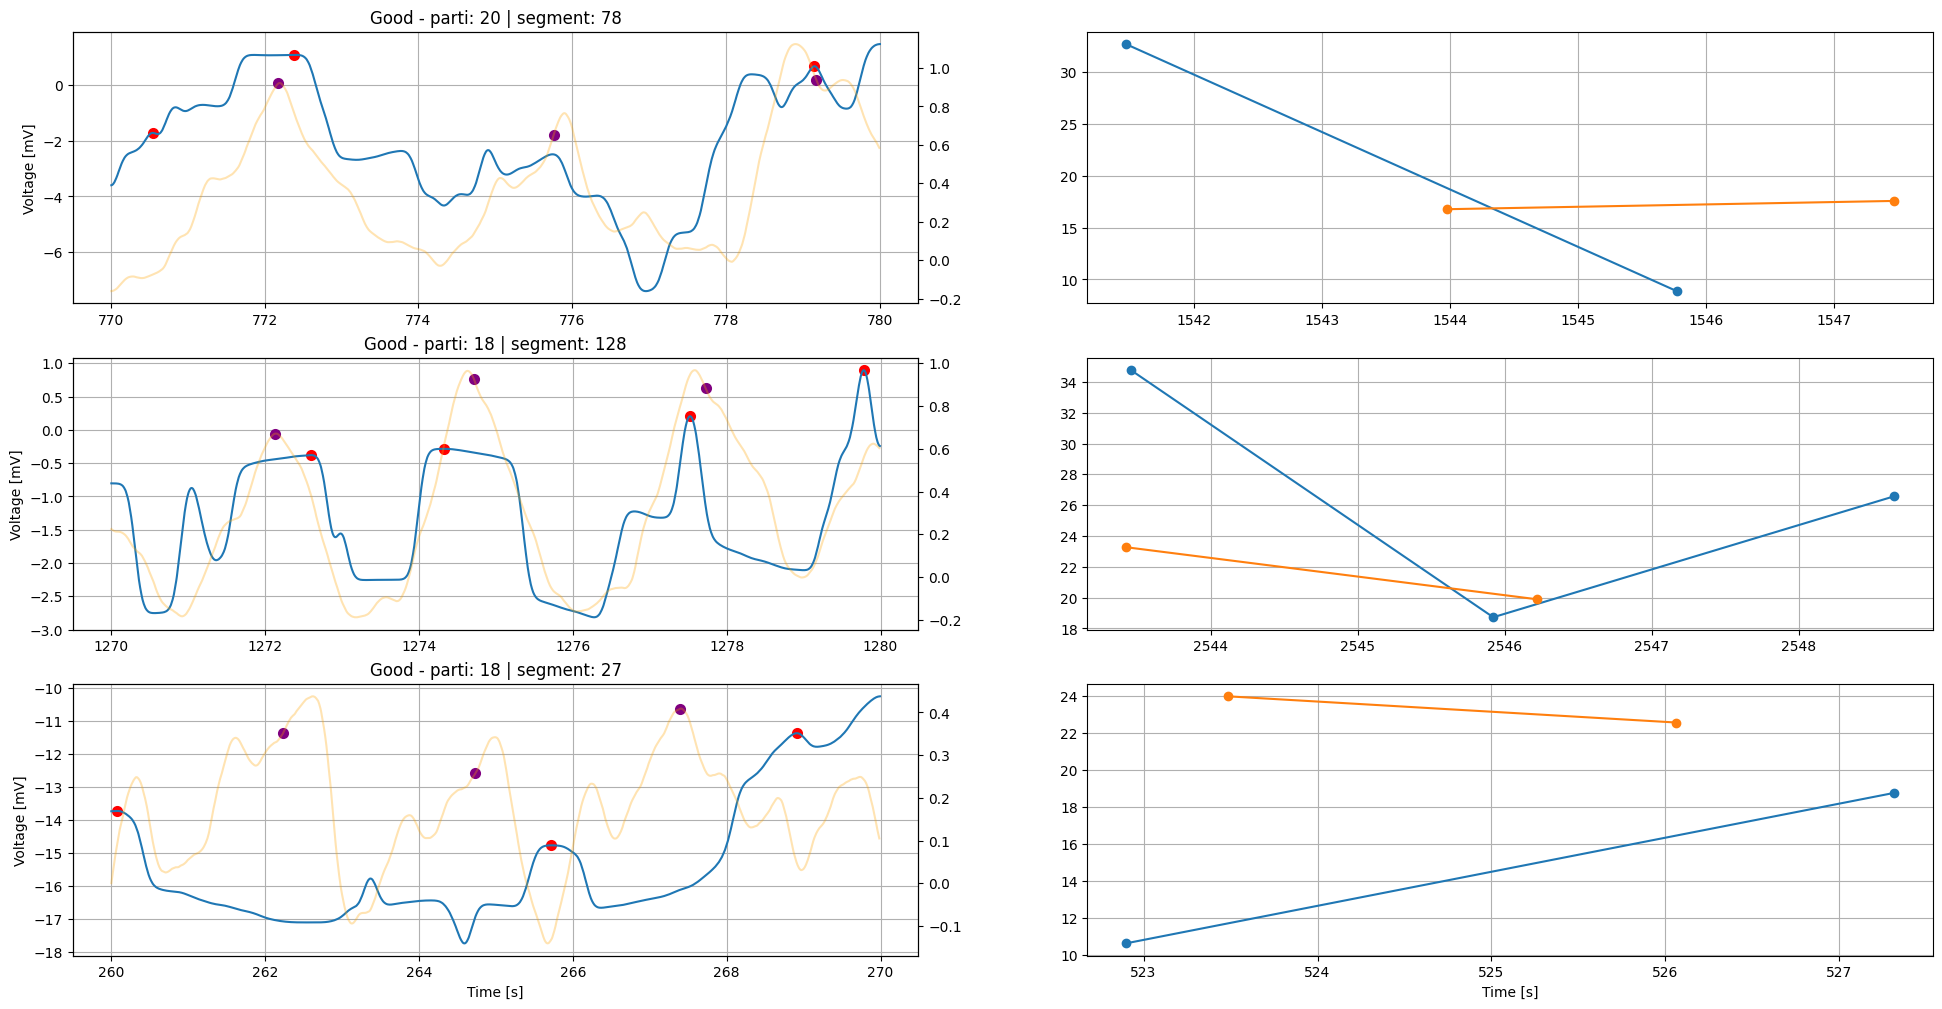

In [16]:
signals = get_random_signals(("good", "no_ma"), ("good", "no_ma"), ("good", "no_ma"))
triple_fig = plot_triple_data(dfs = signals, signal=SIGNAL, title= [f"Good - {signals[0].attrs['signal']}" , f"Good - {signals[1].attrs['signal']}", f"Good - {signals[2].attrs['signal']}"])
# single_fig = plot_single_data(df = signals[1], signal=SIGNAL, qualities= ["Good", "No MA"])
# single_fig_with_hr_rr = plot_single_data_with_hr_rr(df = signals[0], signal=SIGNAL, qualities= ["Good", "No MA"])
# single_fig.savefig("test.pgf")

-----------

### Peak Detection: Cushion Signal

In [62]:
from ma.utils import load_participant_data, put_metadata_to_segments
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
parti17 = load_participant_data(
    participant_number=17,
    signal_names=["mi1"],
    class_name="RR",
    bandpassed=True,
    time_offset=True
)
parti17_data, parti17_labels = load_participant_data(
    participant_number=17,
    signal_names=["mi1"],
    class_name="RR",
    bandpassed=True,
    segmented=True,
    load_labels=True,
    time_offset=True
)
parti17_segmented = put_metadata_to_segments(
    segments=parti17_data, labels=parti17_labels, parti_no=17
)
parti17_resp_ref_segmented = load_participant_data(participant_number=17, signal_names=["resp_ref"],class_name="RR", bandpassed=True, segmented=True, time_offset=True)
parti17_resp_ref = load_participant_data(participant_number=17, signal_names=["resp_ref"],class_name="RR", bandpassed=True, segmented=False, time_offset=True)

In [63]:
def peak_detection(df_segmented:list[pd.DataFrame], distance=40, dynamic_height_multiplier=0.25, prominence=0.2):
    all_peaks = []
    for segment_no, segment in enumerate(df_segmented):
        values = segment.values.ravel()
        # Detect peaks with a minimum distance, height, and prominence
        dynamic_height = np.mean(values) + dynamic_height_multiplier * np.std(values)
        peaks, _ = find_peaks(values, distance=distance, height=dynamic_height, prominence=prominence)

        # It finds the maximum of the peak as default, so modify it
        peak_start_indices = []
        for peak in peaks:
            # Traverse backwards to find where the slope changes
            for i in range(peak, 0, -1):
                if (segment.iloc[i] - segment.iloc[i - 1]).values[0] > 0.075:
                    peak_start_indices.append(i)
                    break
        all_peaks.append(peaks + len(segment) * (segment_no))
    flattened_list = [item for sublist in all_peaks for item in sublist]
    return flattened_list

In [64]:
peaks = peak_detection(df_segmented=parti17_segmented)
peaks_ref = peak_detection(df_segmented=parti17_resp_ref_segmented, distance=20, dynamic_height_multiplier=0.2, prominence=0.1)

In [ ]:
fig, ax = plt.subplots(figsize=(20, 12))
ax.plot(parti17, color="blue", linestyle="-")
ax.scatter(parti17.index[peaks], parti17.iloc[peaks]["scg1x"].values, color = "red")
ax.grid()

ax2 = ax.twinx()
ax2.plot(parti17_resp_ref, color="orange", linestyle="-", alpha = 0.3)
ax2.scatter(parti17_resp_ref.index[peaks_ref], parti17_resp_ref.iloc[peaks_ref]["resp_ref"].values, color = "red")
ax2.grid()